<a href="https://colab.research.google.com/github/kmyers111/ML-Models/blob/main/unsupervised/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [94]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Mall_Customers.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vjchoudhary7/customer-segmentation-tutorial-in-python",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
First 5 records:    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [95]:
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (200, 5)

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column names:
 ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [96]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [97]:
df = df.drop(columns=['CustomerID'])

In [98]:
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Missing values:
 Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicates: 0


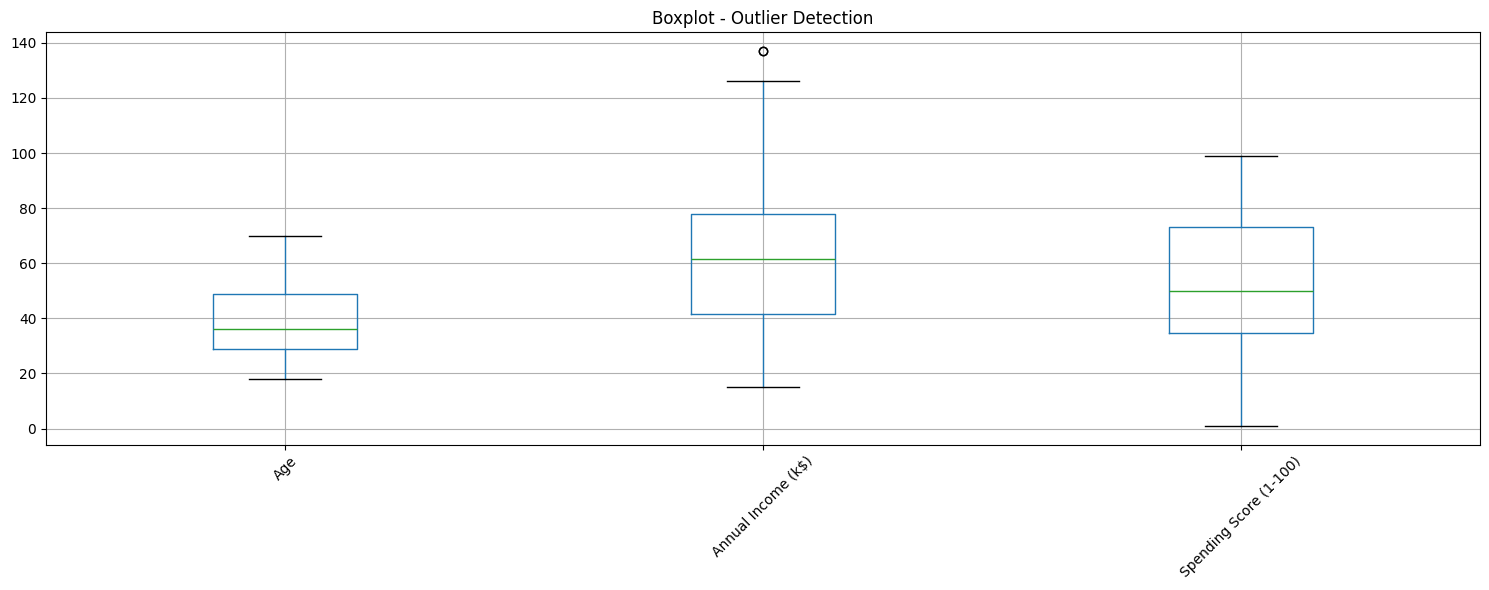

In [99]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot - Outlier Detection")
plt.tight_layout()
plt.show()

In [100]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("After outlier removal:", len(df))

After outlier removal: 198


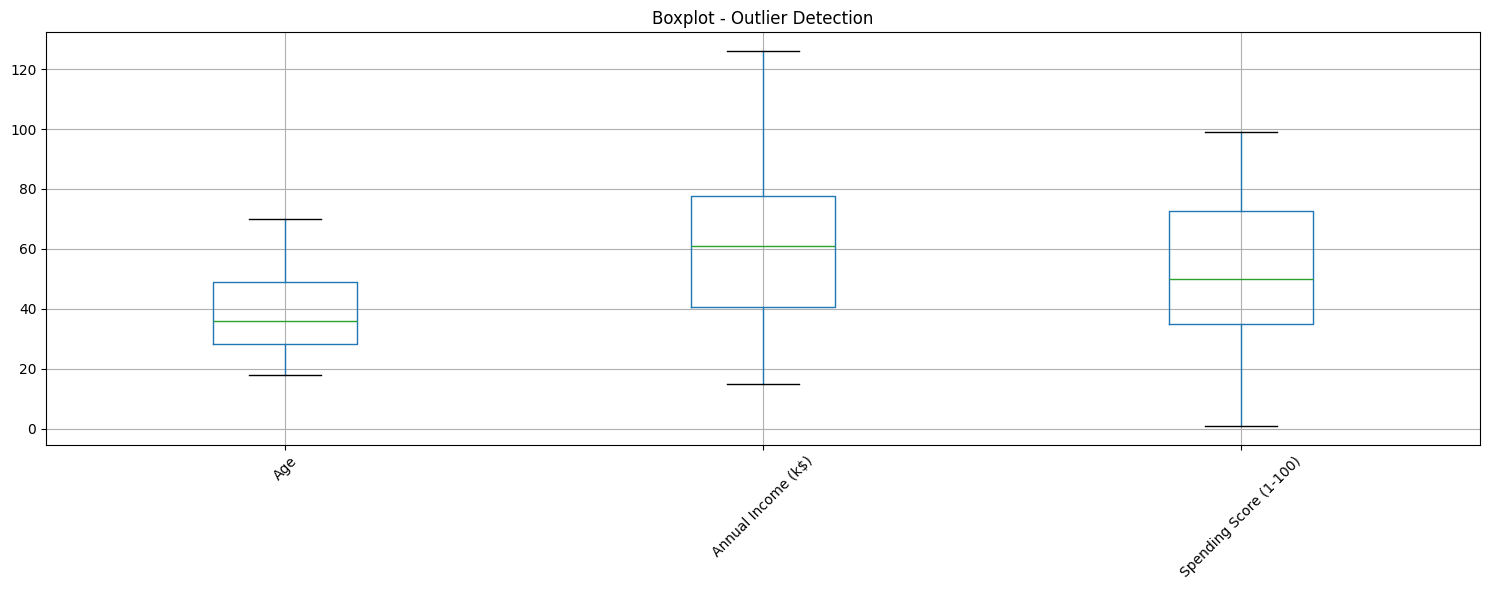

In [101]:
plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot - Outlier Detection")
plt.tight_layout()
plt.show()

In [102]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

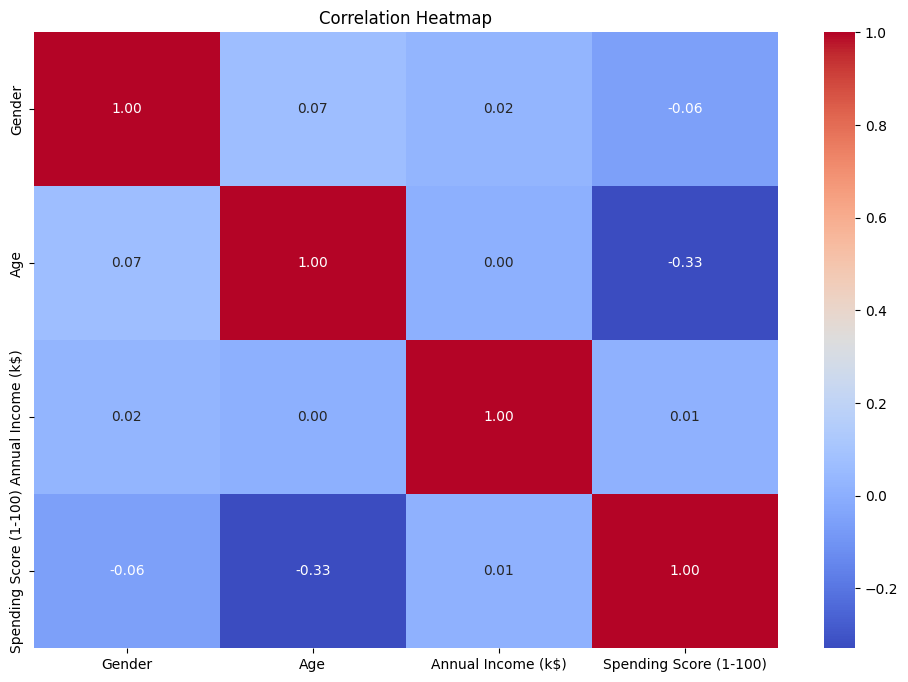

In [103]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))
sb.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

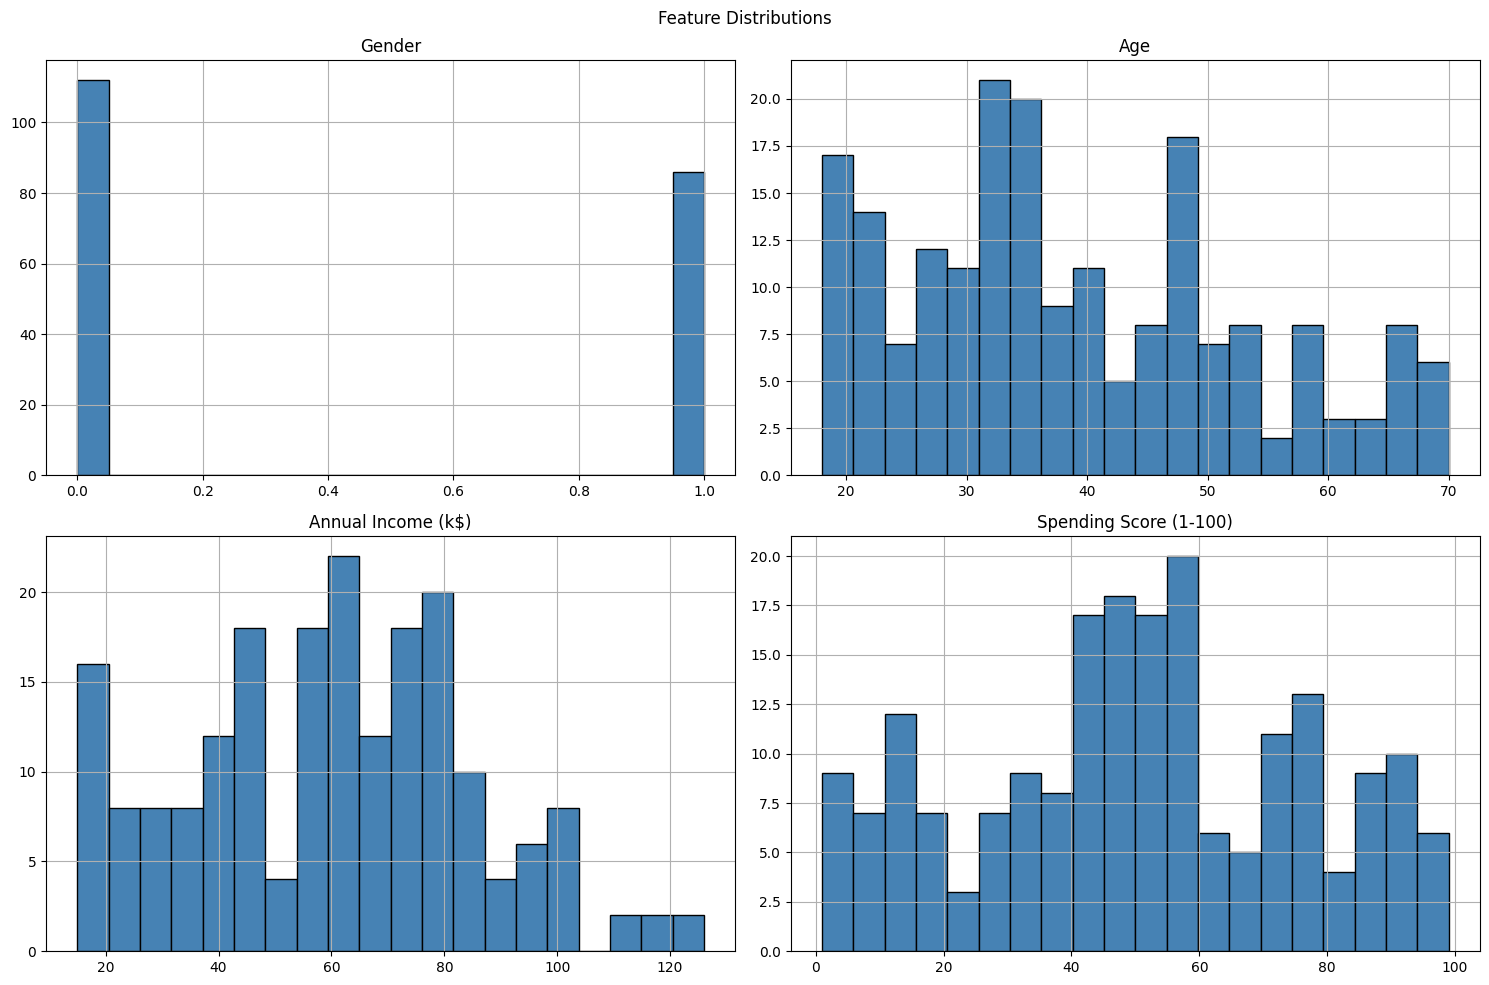

In [104]:
df[numeric_cols].hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

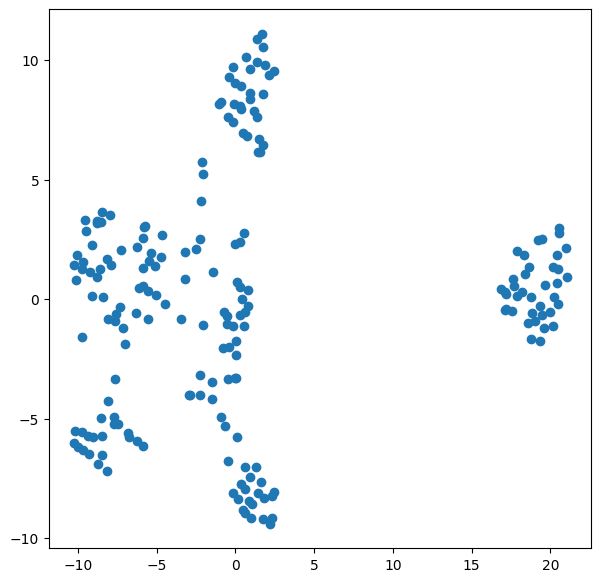

In [105]:
from sklearn.manifold import TSNE
model = TSNE(n_components=2, random_state=0)
tsne_data = model.fit_transform(df)
plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])
plt.show()

In [106]:
error = []
for n_clusters in range(1, 21):
    model = KMeans(init='k-means++',
                   n_clusters=n_clusters,
                   max_iter=500,
                   random_state=22)
    model.fit(df)
    error.append(model.inertia_)

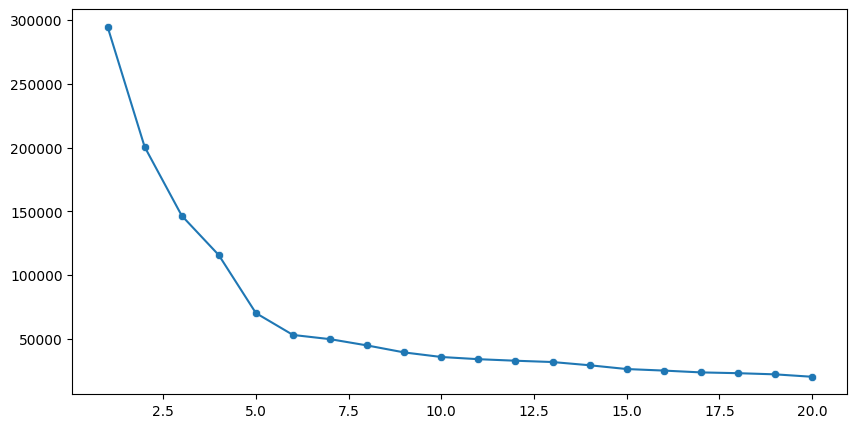

In [107]:
plt.figure(figsize=(10, 5))
sb.lineplot(x=range(1, 21), y=error)
sb.scatterplot(x=range(1, 21), y=error)
plt.show()

In [108]:
model = KMeans(init='k-means++',
               n_clusters=6,
               max_iter=500,
               random_state=22)
segments = model.fit_predict(df)

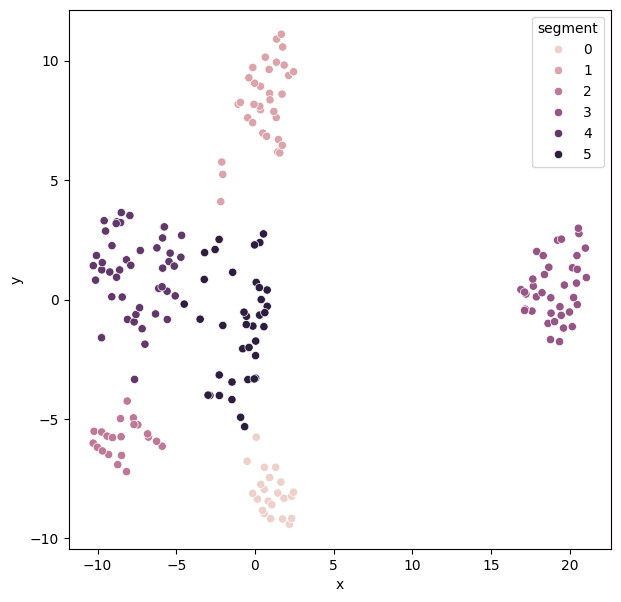

In [109]:
plt.figure(figsize=(7, 7))

df_tsne = pd.DataFrame({'x': tsne_data[:, 0], 'y': tsne_data[:, 1], 'segment': segments})

sb.scatterplot(x='x', y='y', hue='segment', data=df_tsne)
plt.show()

In [110]:
df['Segment'] = segments
score = silhouette_score(df.drop(columns=['Segment']), segments)
print("Silhouette Score:", round(score, 4))
print("\nCluster Summary:")
print(df.groupby('Segment').mean().round(2))

Silhouette Score: 0.4595

Cluster Summary:
         Gender    Age  Annual Income (k$)  Spending Score (1-100)
Segment                                                           
0          0.41  25.27               25.73                   79.36
1          0.56  41.97               86.79                   17.26
2          0.38  44.14               25.14                   19.52
3          0.45  32.76               85.21                   82.11
4          0.44  56.16               53.38                   49.09
5          0.34  27.00               56.66                   49.13
